# Fine-tuning a model on a token classification task

Notebook adapted from [ML4NLP](https://github.com/cltl/ma-ml4nlp-labs/blob/main/code/assignment3/other_systems/bert_finetunen.ipynb), previously adapted from [HuggingFace](https://github.com/huggingface/notebooks/blob/main/examples/token_classification.ipynb)

In this notebook, we will fine-tune a BERT model for Negation Scope Detection.

# Advantages of BERT for Negation Scope Detection

BERT is highly effective for negation scope detection due to its bidirectional architecture, which enables it to process context from both sides of a word simultaneously. This is essential for understanding the scope of negation, which often depends on the context of surrounding words and complex syntactic structures. Additionally, BERT's pretraining on large-scale corpora equips it with a rich understanding of semantic and syntactic patterns, making it adaptable to various domains, where negation usage can differ. Its self-attention mechanism allows it to capture long-range dependencies, ensuring the relationship between negation cues (e.g., "not") and their corresponding scope is effectively modeled, even when separated by multiple intervening words.

For negation scope detection, input preprocessing is critical to fully leverage BERT's capabilities. The input must be tokenized using BERT's WordPiece tokenizer, with careful alignment of token-level labels to handle subwords and multi-token cues like "by no means." Replacing or augmenting negation cues with special tokens during preprocessing can help the model focus on these markers. Input representations should include token IDs, attention masks, and, optionally, token type IDs, while maintaining label consistency across subword tokens and multi-token cues. These steps, combined with BERT's contextualized embeddings, make it well-suited for token classification tasks, enabling precise detection of negation cues and their scopes.

### Model Link
https://drive.google.com/file/d/1-xr7T-IovfoRvN7TcSAjgmnlf0zciv4u/view?usp=sharing


# Code

Let's install the packages we need from HuggingFace

In [1]:
! pip install transformers seqeval evaluate

In [1]:
task = "nsd"
model_checkpoint = "google-bert/bert-base-uncased"
batch_size = 16

## Loading the dataset

In [2]:
import nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

## Duplication
First, the code to duplicate sentences with multiple negation cues, adapted from Assignment 1

In [3]:
def extract(filename):
    """
    Extracts sentences from a file in CONLL format.
    """
    sents = []
    with open(filename, "r") as file:
        lines = [l.split("\t") for l in file.read().splitlines()]

        sent = []
        for i, line in enumerate(lines):

            if line[0] == "":
                sents.append(pd.DataFrame(sent))
                sent = []
                continue

            elif "csv" in filename and "reformatted" not in filename:
                if line[1] != lines[i-1][1] and i != 0 and len(sent) > 0:
                    sents.append(pd.DataFrame(sent))
                    sent = [line]
                    continue

            sent.append(line)

    return sents

def reformat(sents):

    new_sents = []

    for sent in sents:
        # drop syntax col
        sent[6] = ["_" for _ in range(len(sent))]

        # check for any negation
        if len(sent.columns) > 8:
            counter = 0
            for col in sent.columns[7:]:
                # check negation token cols
                if (col - 7) % 3 == 0 and sent[col].nunique() > 1:
                    new_sent = sent.drop(sent.columns[7:], axis=1)
                    new_sent[7] = sent[col]
                    new_sent[8] = sent[col + 1]
                    new_sent[9] = sent[col + 2]
                    new_sent[1] = new_sent[1].apply(lambda x: f"{x}.{counter}" if counter > 0 else x)
                    new_sents.append(new_sent)
                    counter += 1

        else:
            new_sents.append(sent)

    return new_sents

def write_out(sents, filename):
    with open(filename, "w") as file:
        for sent in sents:
            for i, row in sent.iterrows():
                file.write("\t".join(row) + "\n")
            file.write("\n")

def process_file(fname):
  sents = extract(fname)
  new_sents = reformat(sents)
  write_out(new_sents, fname.split("/")[-1][:-4] + "-reformatted.txt")


process_file("starsem-st-2012-data/cd-sco/corpus/dev/SEM-2012-SharedTask-CD-SCO-dev-09032012.txt")
process_file("starsem-st-2012-data/cd-sco/corpus/test-gold/SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD.txt")
process_file("starsem-st-2012-data/cd-sco/corpus/test-gold/SEM-2012-SharedTask-CD-SCO-test-circle-GOLD.txt")
process_file("starsem-st-2012-data/cd-sco/corpus/training/SEM-2012-SharedTask-CD-SCO-training-09032012.txt")

Now we read in the reformatted datasets

In [4]:
def load_data(file_path):
    """
    Load the TSV file into a Pandas DataFrame.
    """

    # Reading data from a TSV file into a DataFrame with specified column names.
    df = pd.read_csv(file_path, delimiter='\t', header=None, names=[
        'chapter', 'sentence_num', 'token_num', 'token', 'lemma',
        'pos', 'constituency', 'cue', 'scope', 'event'
    ])

    df["scope_label"] = ["OS" if scope == "_" else "IN" for scope in df["scope"]]

    df.drop(df[df["cue"] == "***"].index, inplace=True)
    df = df.fillna("")

    return df

In [5]:
train = load_data("SEM-2012-SharedTask-CD-SCO-training-09032012-reformatted.txt")
cardboard = load_data("SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD-reformatted.txt")
circle = load_data("SEM-2012-SharedTask-CD-SCO-test-circle-GOLD-reformatted.txt")
dev = load_data("SEM-2012-SharedTask-CD-SCO-dev-09032012-reformatted.txt")

test = pd.concat([cardboard, circle], ignore_index=True)

In [6]:
# Creating a mapping negation scopes to unique indices.
unique_negation_scopes = sorted(train['scope_label'].unique().tolist())
negation_scope_label_mapping = {label: idx for idx, label in enumerate(unique_negation_scopes)}

## Cue Replacement

Replacing negation cues in sentences with unique tokens, as in NegBERT.

The preprocessing of the input involves replacing negation cues in the text with special tokens (`cue[0]`, `cue[1]`, or `cue[2]`) based on the type and context of the cue. This replacement ensures that the model focuses on these crucial linguistic markers, which play a central role in determining the scope of negation. Additionally, the preprocessing preserves the original structure of the sentence by keeping non-cue tokens unchanged, allowing the model to learn the relationship between cues and their scope effectively.

The function differentiates between:
1. **Affix-based cues** (e.g., "impossible"), which are replaced with `cue[0]` when the token itself is the cue.
2. **Single-token cues** (e.g., "not"), which are replaced with `cue[1]`.
3. **Multi-token cues** (e.g., "by no means"), where all components are replaced with `cue[2]`.


### Example of Preprocessing Steps

#### 1. **Human-Readable Input**
Example Sentence:
> "By no means did she complete the task, though I made sure it was not left unfinished."

Cue Information:
- `"not"` is a single-token cue.
- `"by no means"` is a multi-token cue.
- `"unfinished"` is an affix cue.

Transformed Sentence:
> `"cue[2] cue[2] cue[2] did she complete the task, though I made sure it was cue[1] left cue[0]."`

#### 2. **Machine-Readable Input**
After tokenization using the WordPiece tokenizer, the sentence is split into subwords:
- Transformed tokens: `["cue[2]", "cue[2]", "cue[2]", "did", "she", "complete", "the", "task", ",", "though", "I", "made", "sure", "it", "was", "cue[1]", "left", "cue[0]", "."]`
- Token IDs (after conversion): `[101, 30524, 30524, 30524, 2106, 2016, 3143, 1996, 4708, 1010, 2295, 1045, 2081, 2469, 2009, 2001, 30523, 2187, 30522, 1012, 102]`

Here:
- Cue markers are manually added to the tokenizer's vocabulary with unique IDs (e.g. `"cue[2]" = 30524`, etc.).
- Special tokens like `[CLS]` (`101`) and `[SEP]` (`102`) are automatically added by BERT.

### Why This Approach Works
- **Human-Readable Text**: The special tokens (`cue[0]`, `cue[1]`, `cue[2]`) clearly indicate the presence and type of negation cues, making the input interpretable.
- **Machine-Readable Input**: Subword IDs align with the transformed tokens, ensuring the model can leverage both the cues and surrounding context during training. Multi-token cues are consistently represented, preserving their collective meaning.

This preprocessing method is flexible, scalable for diverse negation patterns, and ensures compatibility with BERT's input format.

In [7]:
def transform_data_with_cue_replacement(df, negation_scope_label_mapping):
    """
    Transform the DataFrame with cue replacement for BERT input.

    Args:
    df (DataFrame): The input data frame.
    negation_scope_label_mapping (dict): Mapping for negation scopes to indices.

    Returns:
    list: A list of dictionaries, each representing a transformed data record.
    """
    # Grouping the data by 'chapter' and 'sentence_num' for processing.
    grouped = df.groupby(['chapter', 'sentence_num'])
    transformed_data = []

    for (chapter, sentence_num), group in grouped:
        tokens = []
        cues = group['cue'].tolist()
        cue_counter = len([cue for cue in cues if cue != "_"])

        # Replace cues with special tokens
        for token, cue_label in zip(group['token'], cues):
          if cue_label != "_":
            if cue_counter > 1:
              tokens.append("cue[2]")
            elif token == cue_label:
              tokens.append("cue[1]")
            else:
              tokens.append("cue[0]")
          else:
            tokens.append(token)

        record = {
            'id': f"{chapter}_{sentence_num}",
            'tokens': tokens,
            'cue': cues,
            'scope_label': [negation_scope_label_mapping[label] for label in group['scope_label'].tolist()],
        }
        transformed_data.append(record)
        
    return transformed_data


In [8]:
transformed_training_data = transform_data_with_cue_replacement(train, negation_scope_label_mapping)
transformed_test_data = transform_data_with_cue_replacement(test, negation_scope_label_mapping)
transformed_dev_data = transform_data_with_cue_replacement(dev, negation_scope_label_mapping)

## Creating HuggingFace style Datset

In [9]:
from datasets import Dataset, Features, Value, Sequence, ClassLabel, DatasetDict

In [10]:
# Defining the features for the Hugging Face dataset.
features = Features({
    'id': Value(dtype='string'),
    'tokens': Sequence(feature=Value(dtype='string')),
    'cue': Sequence(feature=Value(dtype='string')),
    'scope_label': Sequence(feature=ClassLabel(names=unique_negation_scopes)),
})

In [11]:
# Converting the transformed data to Hugging Face datasets.
hf_training_dataset = Dataset.from_pandas(pd.DataFrame(transformed_training_data), features=features)
hf_test_dataset = Dataset.from_pandas(pd.DataFrame(transformed_test_data), features=features)
hf_dev_dataset = Dataset.from_pandas(pd.DataFrame(transformed_dev_data), features=features)

In [12]:
# Creating a DatasetDict to hold the training, validation, and test datasets.
dataset_dict = DatasetDict({
    'train': hf_training_dataset,
    'validation': hf_dev_dataset,
    'test': hf_test_dataset
})

In [13]:
label_list = dataset_dict["train"].features["scope_label"].feature.names
label_list

['IN', 'OS']

In [14]:
from datasets import ClassLabel, Sequence
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)

    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
        elif isinstance(typ, Sequence) and isinstance(typ.feature, ClassLabel):
            df[column] = df[column].transform(lambda x: [typ.feature.names[i] for i in x])
    display(HTML(df.head(5).to_html()))

In [15]:
show_random_elements(dataset_dict["train"])

,id,tokens,cue,scope_label
0,baskervilles07_260.0,"[``, Why, ,, you, had, cue[1], very, much, time, for, talk, ,, '', her, brother, remarked, with, the, same, questioning, eyes, .]","[_, _, _, _, _, not, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _]","[OS, OS, OS, IN, IN, OS, IN, IN, IN, IN, IN, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS]"
1,baskervilles11_236.0,"[cue[1], would, induce, me, to, help, the, police, in, any, way, .]","[Nothing, _, _, _, _, _, _, _, _, _, _, _]","[OS, IN, IN, IN, IN, IN, IN, IN, IN, IN, IN, OS]"
2,baskervilles10_110.0,"[``, cue[1], ,, sir, ,, it, crumbled, all, to, bits, after, we, moved, it, ., '']","[_, No, _, _, _, _, _, _, _, _, _, _, _, _, _, _]","[OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS]"
3,baskervilles05_178.1,"[The, German, was, sent, for, but, professed, to, know, nothing, of, the, matter, ,, cue[1], could, any, inquiry, clear, it, up, .]","[_, _, _, _, _, _, _, _, _, _, _, _, _, _, nor, _, _, _, _, _, _, _]","[OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, IN, IN, IN, IN, IN, IN, OS]"
4,baskervilles06_114.1,"[``, No, ,, cue[1], ,, the, yew, alley, is, on, the, other, side, ., '']","[_, _, _, no, _, _, _, _, _, _, _, _, _, _, _]","[OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS, OS]"


## Preprocessing the data

Before we can feed those texts to our model, we need to preprocess them. This is done by a 🤗 Transformers `Tokenizer` which will (as the name indicates) tokenize the inputs (including converting the tokens to their corresponding IDs in the pretrained vocabulary) and put it in a format the model expects, as well as generate the other inputs that model requires.

To do all of this, we instantiate our tokenizer with the `AutoTokenizer.from_pretrained` method, which will ensure:

- we get a tokenizer that corresponds to the model architecture we want to use,
- we download the vocabulary used when pretraining this specific checkpoint.

That vocabulary will be cached, so it's not downloaded again the next time we run the cell.

In [16]:
import transformers
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForTokenClassification.from_pretrained(model_checkpoint, num_labels=len(label_list))

Some weights of BertForTokenClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


We add our specially defined tokens to mark cues into the Tokenizer's vocabulary

In [17]:
special_tokens = ['cue[0]', 'cue[1]', 'cue[2]']
tokenizer.add_special_tokens({'additional_special_tokens': special_tokens})
model.resize_token_embeddings(len(tokenizer))

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(30525, 768, padding_idx=0)

In [20]:
label_all_tokens = True

We're now ready to write the function that will preprocess our samples. We feed them to the `tokenizer` with the argument `truncation=True` (to truncate texts that are bigger than the maximum size allowed by the model) and `is_split_into_words=True` (as seen above). Then we align the labels with the token ids using the following strategy:

We set the labels of all special tokens to -100 (the index that is ignored by PyTorch) and the labels of all other tokens to the label of the word they come from. Another strategy is to set the label only on the first token obtained from a given word, and give a label of -100 to the other subtokens from the same word.

In [21]:
def tokenize_and_align_labels(examples):
    
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples["scope_label"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            # Special tokens have a word id that is None. We set the label to -100 so they are automatically
            # ignored in the loss function.
            if word_idx is None:
                label_ids.append(-100)
            # We set the label for the first token of each word.
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # For the other tokens in a word, we set the label to either the current label or -100, depending on
            # the label_all_tokens flag.
            else:
                label_ids.append(label[word_idx] if label_all_tokens else -100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    
    return tokenized_inputs

To apply this function on all the sentences (or pairs of sentences) in our dataset, we just use the `map` method of our `dataset` object we created earlier. This will apply the function on all the elements of all the splits in `dataset`, so our training, validation and testing data will be preprocessed in one single command.

In [ ]:
tokenized_datasets = dataset_dict.map(tokenize_and_align_labels, batched=True)

Remove additional features (don't give scope_label as a feature!)

In [23]:
parsed_datasets = {}
for key, dataset in tokenized_datasets.items():
    
    new_data = []
    for sent in dataset:
        new_sent = {}
        new_sent["input_ids"] = sent["input_ids"]
        new_sent["labels"] = sent["labels"]
        new_sent["attention_mask"] = sent["attention_mask"]
        new_data.append(new_sent)

    parsed_datasets[key] = new_data

## Example Model Input

In [24]:
parsed_datasets["train"][0]

{'input_ids': [101,
  2720,
  1012,
  20052,
  9106,
  1010,
  2040,
  2001,
  2788,
  2200,
  2397,
  1999,
  1996,
  16956,
  1010,
  3828,
  2588,
  2216,
  2025,
  30522,
  6642,
  2043,
  2002,
  2001,
  2039,
  2035,
  2305,
  1010,
  2001,
  8901,
  2012,
  1996,
  6350,
  2795,
  1012,
  102],
 'labels': [-100,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  -100],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1]}

## Fine-tuning the model

Now that our data is ready, we can download the pretrained model and fine-tune it. Since all our tasks are about token classification, we use the `AutoModelForTokenClassification` class. Like with the tokenizer, the `from_pretrained` method will download and cache the model for us. The only thing we have to specify is the number of labels for our problem (which we can get from the features)

Next, to we instantiate a `Trainer`, we define three more things. The most important is the [`TrainingArguments`](https://huggingface.co/transformers/main_classes/trainer.html#transformers.TrainingArguments), which is a class that contains all the attributes to customize the training. It requires one folder name, which will be used to save the checkpoints of the model, and all other arguments are optional:

In this assignment, you will experiment with different random seeds and see what the outcome is on the performance of the model. The random seed influences the following steps when training (amongst others):


*  **Weight Initialization:** When we start training, the values for the weights are randomly assigned. This is controlled by the random seed. This impacts the training trajectory in the weight space, e.g. determines which local minimum the model can end up in.
*  **Data Order**: The order in which the model sees the data is also controlled by the random seed. This also influences the training trajectory, determining which data points are e.g. influential in the beginning.


Setting the random seed with a specific numerical value (e.g. 0) makes sure that we can reproduce the results again, introducing some kind of deterministic behavior.

In [25]:
from transformers import set_seed
import random

# Set random seed!
# SEED = random.randint(0,1000000)
SEED = 42
print(SEED)
set_seed(SEED)

model_name = model_checkpoint.split("/")[-1]
args = TrainingArguments(
    f"{model_name}-finetuned-{task}",
    eval_strategy = "epoch",
    logging_dir="./logs",                #Dir to save logs
    logging_strategy="steps",           #log at regular steps
    logging_steps=1,                    #log training loss at every step
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=10,
    weight_decay=0.01,
    seed=SEED,
    report_to="none",
)

42


Then we will need a data collator that will batch our processed examples together while applying padding to make them all the same size (each pad will be padded to the length of its longest example). There is a data collator for this task in the Transformers library, that not only pads the inputs, but also the labels:

In [26]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

The last thing to define for our `Trainer` is how to compute the metrics from the predictions. Here we will load the [`seqeval`](https://github.com/chakki-works/seqeval) metric (which is commonly used to evaluate results on the CONLL dataset) via the Datasets library.

In [27]:
from evaluate import load

metric = load("seqeval")

This metric takes a list of labels for the predictions and references:

In [28]:
def compute_metrics(p):
    predictions, labels = p

    # Find the index with the maximum logit for each token (argmax over the last dimension).
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100), convert predicted and true labels to their string representations.
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Calculate evaluation metrics using 'metric.compute'.
    results = metric.compute(predictions=true_predictions, references=true_labels)

    # Return a dictionary containing precision, recall, F1 score, and accuracy.
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

So we will need to do a bit of post-processing on our predictions:
- select the predicted index (with the maximum logit) for each token
- convert it to its string label
- ignore everywhere we set a label of -100

The following function does all this post-processing on the result of `Trainer.evaluate` (which is a namedtuple containing predictions and labels) before applying the metric:

Note that we drop the precision/recall/f1 computed for each category and only focus on the overall precision/recall/f1/accuracy.

Then we just need to pass all of this along with our datasets to the `Trainer`:

In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=parsed_datasets["train"],
    eval_dataset=parsed_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

We can now finetune our model by just calling the `train` method:

In [30]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.346700,0.436894,0.366864,0.417508,0.390551,0.799794
2,0.048900,0.367123,0.586885,0.602694,0.594684,0.866872
3,0.215200,0.373063,0.588235,0.606061,0.597015,0.874325
4,0.030900,0.307106,0.650000,0.700337,0.674230,0.903624
5,0.019600,0.364086,0.667702,0.723906,0.694669,0.902853
6,0.007100,0.452469,0.656051,0.693603,0.674304,0.897713
7,0.014600,0.406102,0.679878,0.750842,0.713600,0.914675
8,0.017100,0.463192,0.678125,0.730640,0.703404,0.905166
9,0.001200,0.457029,0.676923,0.740741,0.707395,0.906965
10,0.007700,0.456084,0.690184,0.757576,0.722311,0.910306


/Users/rhea/MyWorkspace/VU/Applied TM/Assign2/.venv_a2/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: IN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/Users/rhea/MyWorkspace/VU/Applied TM/Assign2/.venv_a2/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: OS seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/Users/rhea/MyWorkspace/VU/Applied TM/Assign2/.venv_a2/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: IN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/Users/rhea/MyWorkspace/VU/Applied TM/Assign2/.venv_a2/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: OS seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/Users/rhea/MyWorkspace/VU/Applied TM/Assign2/.venv_a2/lib/python3.11/site-packages/seqeval/metr

TrainOutput(global_step=620, training_loss=0.0995140527410718, metrics={'train_runtime': 214.4049, 'train_samples_per_second': 45.848, 'train_steps_per_second': 2.892, 'total_flos': 279599777992992.0, 'train_loss': 0.0995140527410718, 'epoch': 10.0})

The `evaluate` method allows you to evaluate again on the evaluation dataset or on another dataset:

In [31]:
trainer.evaluate()

{'eval_loss': 0.45608362555503845,
 'eval_precision': 0.6901840490797546,
 'eval_recall': 0.7575757575757576,
 'eval_f1': 0.7223113964686998,
 'eval_accuracy': 0.9103058339758416,
 'eval_runtime': 2.3263,
 'eval_samples_per_second': 61.902,
 'eval_steps_per_second': 3.869,
 'epoch': 10.0}

In [32]:
# Save the model and tokenizer
model_save_path = "model"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

('model/tokenizer_config.json',
 'model/special_tokens_map.json',
 'model/vocab.txt',
 'model/added_tokens.json',
 'model/tokenizer.json')

To get the precision/recall/f1 computed for each category now that we have finished training, we can apply the same function as before on the result of the `predict` method:

## Realignment & Postprocessing

The process of handling the output of the model involves aligning the subword-level predictions made by the model back to the token-level predictions required by the shared task. This alignment ensures that the system's predictions match the original tokenization of the dataset. Since BERT uses subword tokenization (e.g., "unbelievable" → ["un", "##believable"]), the output predictions are at the subword level and must be aggregated back to token level.

### Output Processing Pipeline

   - For each token in the input, the tokenizer may produce multiple subwords. For example, the token `"unbelievable"` might tokenize into `["un", "##believable"]`. 
   - Each subword gets a separate prediction from the model. To align these subword predictions with the original token, we decide to consider only the prediction for the first subword.

   - BERT introduces special tokens like `[CLS]` and `[SEP]` that are not part of the original input. These are excluded from the final predictions by skipping the first (`[CLS]`) and last (`[SEP]`) predictions.

   - For tokens that were split into multiple subwords, we use a simple First Subword Heuristic to assign a single label to the entire token - meaning the prediction for the first subword is used as the label for the entire token. This approach works well for tasks like negation scope detection, where most of the information is captured in the first subword.

---

### Example with Subword Splitting

#### Original Sentence:
> `"She found the movie unbelievable."`

#### Tokenized Input:
> `["She", "found", "the", "movie", "unbelievable", "."]`

#### Subword Tokenization:
> `["She", "found", "the", "movie", "un", "##believable", "."]`

#### Model Predictions (Subword Level):
> `["OS", "OS", "OS", "OS", "IN", "IN", "OS"]`

#### Final Token-Level Predictions:
> `["OS", "OS", "OS", "OS", "IN", "OS"]`

---

### Why This Approach Works

The system's final predictions match the token-level granularity required by the shared task. Additonally, the first subword heuristic is simple yet effective for tasks like negation scope detection, where the key signal is often present in the first subword. Another option would be majority voting, but this may leave words which are split into an even number of subtokens undecided.

In [33]:
predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions, axis=2)

aligned_preds = []
aligned_golds = []
for ix, pred in enumerate(predictions):
    
    pred = pred[1:]
    tokens = tokenized_datasets["test"][ix]["tokens"]
    golds = labels[ix][1:-1]

    st_ix = 0
    new_preds = []
    new_golds = []
    for token in tokens:
        subtokens = tokenizer.encode(token)[1:-1]
        token_gold = golds[st_ix:st_ix+len(subtokens)][0]
        new_golds.append(token_gold)

        # take first subword prediction as whole prediction
        st_pred = pred[st_ix:st_ix+len(subtokens)][0]
        new_preds.append(st_pred)
        
        st_ix += len(subtokens)


    aligned_preds.append(new_preds)
    aligned_golds.append(new_golds)

# Results

In [34]:
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(aligned_preds, aligned_golds)
]

true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(aligned_preds, aligned_golds)
]

test_flat = [x for xs in true_labels for x in xs]
pred_flat = [x for xs in true_predictions for x in xs]

print(classification_report(test_flat, pred_flat))

              precision    recall  f1-score   support

          IN       0.94      0.87      0.90      1826
          OS       0.94      0.97      0.96      3884

    accuracy                           0.94      5710
   macro avg       0.94      0.92      0.93      5710
weighted avg       0.94      0.94      0.94      5710



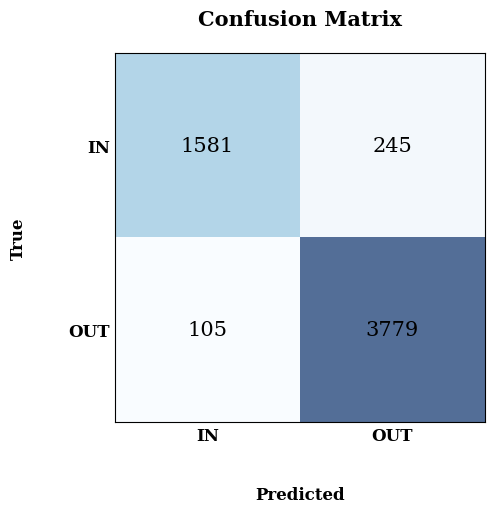

In [35]:
import matplotlib.pyplot as plt

conf = confusion_matrix(test_flat, pred_flat)

fig, ax = plt.subplots()

ax.matshow(conf, cmap='Blues', alpha=0.7)

for (i, j), z in np.ndenumerate(conf):
    ax.text(j, i, '{:0}'.format(z), ha='center', va='center', fontsize=15, fontdict={"family": "serif"})

ax.grid(False)

plt.title("Confusion Matrix", fontsize=15, fontdict={"weight": "bold", "family": "serif"}, pad=20)

ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.xticks(range(2), ["IN", "OUT"], fontsize=12, fontdict={"weight": "bold", "family": "serif"}, )
plt.yticks(range(2), ["IN", "OUT"], fontsize=12, fontdict={"weight": "bold", "family": "serif"})
plt.xlabel("Predicted", labelpad=30, fontsize=12, fontdict={"weight": "bold", "family": "serif"})
plt.ylabel("True", labelpad=30, fontsize=12, fontdict={"weight": "bold", "family": "serif"})
plt.show()

## Discussion of Results

These results are considerably better than those of our CRF model (shown below), demonstrating BERT's ability to capture complex contextual relationships and long-range dependencies, which are critical for accurately identifying negation cues and their scopes. Unlike the CRF model, which relies on manually designed features and struggles with ambiguous or syntactically complex sentences, BERT's pretraining on large-scale corpora allows it to generalize effectively across diverse sentence structures.

### Results from A2 with CRF

Run on slightly different tokenisation - will need to be updated to reflect real token count

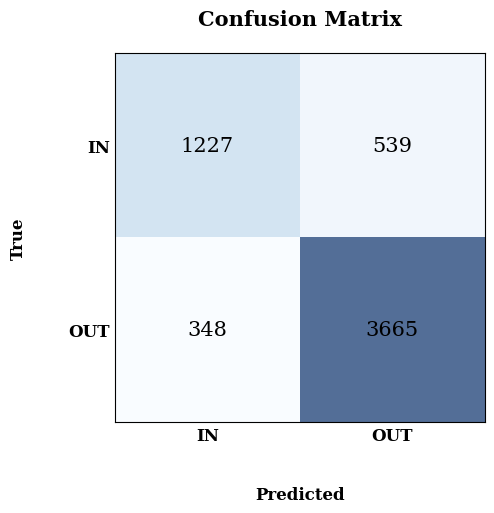
```
              precision    recall  f1-score   support

          IN       0.78      0.69      0.73      1766
           _       0.87      0.91      0.89      4013

    accuracy                           0.85      5779
   macro avg       0.83      0.80      0.81      5779
weighted avg       0.84      0.85      0.84      5779
```


### Result comparison with other team members
Across the different seeds tested by the team members (seed= 42, 295485,904347, 987875),the results were consistent with slight variations in f1-score, precision and recall. All have accuracy ranging between 93-94%. This tells us that the model is robust in its negation scope detection regardless of the seed.

Overall, seed 42 very slightly outperforms the others in terms of precision(94%), recall(87%) in predicting class `IN`. While the other seeds achieve identical results with precision(93%) and recall(86%) for `IN`. For the `OUT` labels precision, recall and f1 scores are the same over all the seeds.
We can say that the results are stable across all the seeds, and it tells us that the model is less sensitive to random initializations and is able to generalize over the data.

### Saving test set predictions in a tsv file

In [39]:
flat_tokens = [x for xs in [sent["tokens"] for sent in tokenized_datasets["test"]] for x in xs]
output = pd.DataFrame({"token": flat_tokens, "true label": test_flat, "prediction": pred_flat})
output.to_csv("test_predictions.tsv", sep="\t")

# Statistics

In [40]:
def generate_stats(sents, dev=False):
    token_counter = 0
    neg_cues = []
    scopes = []
    neg_token_counter = 0

    for sent in sents:
        token_counter += len(sent)
        if len(sent.columns) > 8:
            for col in sent.columns[7:]:
                # check negation token cols
                if (col - 7) % 3 == 0:
                    neg_token = " ".join([token.lower() for token in sent[col].values if token != "_" and token != "***"])
                    if neg_token != "":
                        neg_cues.append(neg_token)

                    neg_token_counter += len(sent)
                    
                    scope = [token for token in sent[col+1].values if token != "_"]
                    scopes.append(scope)

    print("Number of sentences: ", len(sents))

    print("Total number of tokens: ", token_counter)

    print("Number of negation cue instances: ", len(neg_cues))

    print("Number of unique negation cue forms: ", len(set(neg_cues)))

    print("Number of tokens in sentences with negation: ", neg_token_counter)

    scope_len = sum([len(scope) for scope in scopes])
    print("Number of tokens in scope: ", scope_len)

    print("Number of tokens outside scope: ", token_counter - scope_len)

    if dev:
        print("Negation cue forms: ")
        for count in nltk.FreqDist(neg_cues).most_common():
            print("  ", count)

In [41]:
print("Dev")
generate_stats(extract("SEM-2012-SharedTask-CD-SCO-dev-09032012-reformatted.txt"), True)
print("\n")

print("Test (Circle + Cardboard)")
circle = extract("SEM-2012-SharedTask-CD-SCO-test-circle-GOLD-reformatted.txt")
cardboard = extract("SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD-reformatted.txt")
generate_stats(circle + cardboard)
print("\n")

print("Train")
generate_stats(extract("SEM-2012-SharedTask-CD-SCO-training-09032012-reformatted.txt"))

Dev
Number of sentences:  815
Total number of tokens:  14258
Number of negation cue instances:  173
Number of unique negation cue forms:  20
Number of tokens in sentences with negation:  3592
Number of tokens in scope:  1368
Number of tokens outside scope:  12890
Negation cue forms: 
   ('not', 42)
   ('no', 32)
   ("n't", 20)
   ('un', 16)
   ('nothing', 16)
   ('never', 11)
   ('without', 7)
   ('im', 6)
   ('in', 5)
   ('nor', 4)
   ('less', 3)
   ('neither nor', 2)
   ('dis', 2)
   ('no nor', 1)
   ('by no means', 1)
   ('neither', 1)
   ('ir', 1)
   ('save', 1)
   ('nobody', 1)
   ('no more', 1)


Test (Circle + Cardboard)
Number of sentences:  1118
Total number of tokens:  19915
Number of negation cue instances:  264
Number of unique negation cue forms:  20
Number of tokens in sentences with negation:  5710
Number of tokens in scope:  1826
Number of tokens outside scope:  18089


Train
Number of sentences:  3779
Total number of tokens:  69155
Number of negation cue instances:  98

## Ready-to-use Function

In [5]:
def detect_negation_scope(model, tokenizer, sentence, cue_positions, label_list, special_tokens=['cue[0]', 'cue[1]', 'cue[2]']):
    """
    Function to detect negation scope in a sentence.

    Returns:
    negation_scope: A list of scope labels corresponding to each token in the sentence.
    """

    # Replace cues with special tokens based on cue_positions
    processed_sentence = [special_tokens[0] if cue else token for token, cue in zip(sentence, cue_positions)]


    # Tokenize the sentence
    inputs = tokenizer(processed_sentence,
            is_split_into_words=True,
            return_tensors="pt",
            padding=True,
            truncation=True)

    # Forward pass through the model
    with torch.no_grad():
        outputs = model(**inputs)

    # Get the predicted labels for each token
    predictions = torch.argmax(outputs.logits, dim=2).squeeze().numpy()

    # Align predictions with original tokens
    word_ids = inputs.word_ids()
    aligned_predictions = []
    previous_word_id = None
    for word_id, pred in zip(word_ids, predictions):
      if word_id is not None and word_id != previous_word_id:
          aligned_predictions.append(pred)
      previous_word_id = word_id

    # Map predictions to their corresponding labels
    negation_scope = [label_list[pred] for pred in aligned_predictions]

    #debugging and checking alignments
    print(f"Original sentence: {' '.join(sentence)}")
    # print(f"Processed sentence: {processed_sentence}")
    # print(f"Tokens: {inputs.tokens()}")
    # print(f"Word IDs: {inputs.word_ids()}")
    # print(f"Raw predictions: {predictions}")
    print(f"Final predicted negation scope: {negation_scope}")

    # Return the negation scope labels
    return negation_scope


In [6]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch
import numpy as np

sentence = ['John', 'had', 'never', 'said', 'as', 'much', 'before', '.']
cue_positions = [0, 0, 1, 0, 0, 0, 0, 0]


# Load the saved model and tokenizer
model = AutoModelForTokenClassification.from_pretrained("model")
tokenizer = AutoTokenizer.from_pretrained("model")

negation_scope = detect_negation_scope(model, tokenizer, sentence, cue_positions, label_list= ['IN', 'OS'])

Original sentence: John had never said as much before .
Final predicted negation scope: ['IN', 'IN', 'OS', 'IN', 'IN', 'IN', 'IN', 'OS']
